# Tarea 13

## Imports

In [157]:
# Cell: Imports and environment detection
import os, time, math
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

# Detect CuPy (GPU) availability
try:
    import cupy as cp
    gpu_available = True
    print('CuPy available. GPU mode possible.')
except Exception:
    cp = None
    gpu_available = False
    print('CuPy not available; GPU mode disabled.')


CuPy available. GPU mode possible.


## Funciones auxiliares

In [158]:
def get_xp(use_gpu=False):
    if use_gpu and gpu_available:
        return cp
    return np

def qpsk_mod_bits_to_symbols(bits, xp):
    b0 = 1 - 2*bits[...,0]
    b1 = 1 - 2*bits[...,1]
    return (b0 + 1j*b1) / xp.sqrt(2)

def qpsk_demod_symbols_to_bits(symbols, xp):
    bits0 = (symbols.real < 0).astype(xp.int8)
    bits1 = (symbols.imag < 0).astype(xp.int8)
    return xp.stack([bits0, bits1], axis=-1)

def awgn_noise(shape, N0, xp):
    sigma = xp.sqrt(N0/2.0)
    return sigma * (xp.random.normal(size=shape) + 1j * xp.random.normal(size=shape))

def ber_qpsk_awgn(EbN0_lin):
    return 0.5 * erfc(np.sqrt(EbN0_lin))

def ber_qpsk_rayleigh(EbN0_lin):
    return 0.5 * (1 - np.sqrt(EbN0_lin / (1 + EbN0_lin)))

# ========== CHECKPOINT QPSK ==========
xp_test = np
bits_test = xp_test.random.randint(0,2,(50000,2))
s_test = qpsk_mod_bits_to_symbols(bits_test, xp_test)
print("\n>>> CHECKPOINT QPSK MOD <<<")
print("E[|s|^2] ≈", np.mean(np.abs(s_test)**2), " (esperado ≈ 1)")



>>> CHECKPOINT QPSK MOD <<<
E[|s|^2] ≈ 1.0  (esperado ≈ 1)


## Generador de canales MIMO Rayleigh

In [159]:
# Cell: Batch generators for Rayleigh channels and QPSK symbols
def gen_rayleigh_channel_batch(N, Nr, Nt, xp):
    # H ~ CN(0,1)
    real = xp.random.normal(size=(N, Nr, Nt))
    imag = xp.random.normal(size=(N, Nr, Nt))
    return (real + 1j*imag) / xp.sqrt(2.0)

def gen_qpsk_symbols_batch(N, d, Ns, Es_per_stream, xp):
    # bits: (N, d, Ns, 2)
    bits = xp.random.randint(0, 2, size=(N, d, Ns, 2))
    S = qpsk_mod_bits_to_symbols(bits, xp)  # (N,d,Ns)
    S = S * xp.sqrt(Es_per_stream)         # scale so energy per stream matches Es_per_stream
    return S, bits

# ===== CHECKPOINT CHANNEL =====
H_test = gen_rayleigh_channel_batch(200000, 2, 2, np)
print("\n>>> CHECKPOINT RAYLEIGH H <<<")
print("mean real:", H_test.real.mean())
print("var real:", H_test.real.var(), " (esperado ≈ 0.5)")


>>> CHECKPOINT RAYLEIGH H <<<
mean real: 0.00130974350071394
var real: 0.5003920606727381  (esperado ≈ 0.5)


## Simulación de transmisión precodificada y decodificación en canal SDV

In [160]:
def svd_via_hhH_eig_batch(H, xp):
    N, Nr, Nt = H.shape
    HH = xp.matmul(H.conj().transpose(0,2,1), H)

    if xp is not np and getattr(xp.linalg, 'eigh', None) is not None:
        w, V = xp.linalg.eigh(HH)
        w = w[:, ::-1]
        V = V[:, :, ::-1]
        S = xp.sqrt(xp.maximum(w,0))
        return S, V

    S_list, V_list = [], []
    for i in range(N):
        wi, Vi = np.linalg.eigh(HH[i])
        wi = wi[::-1]
        Vi = Vi[:, ::-1]
        S_list.append(np.sqrt(np.maximum(wi,0)))
        V_list.append(Vi)
    return np.stack(S_list), np.stack(V_list)

# ===== CHECKPOINT SVD =====
Hsmall = gen_rayleigh_channel_batch(1, 2, 2, np)[0]
Ss, Vs = svd_via_hhH_eig_batch(Hsmall[None], np)
print("\n>>> CHECKPOINT SVD <<<")
print("V.H @ V ≈ I ?", np.allclose(Vs[0].conj().T @ Vs[0], np.eye(2), atol=1e-6))


>>> CHECKPOINT SVD <<<
V.H @ V ≈ I ? True


In [161]:
# Cell: BER from singular values (the correct averaged BER for fading)
def compute_ber_from_singulars(Svals_d, Es, N0, xp=np):
    """
    Calcula la BER promediada sobre el canal mediante:
        BER = E[ 0.5*erfc( sqrt( gamma_k(H) ) ) ]
    donde gamma_k(H) = (Es/d / N0) * sigma_k^2

    Svals_d : array (Nreal, d) con las singular values por canal
    Es       : energía total por símbolo en la transmisión MIMO
    N0       : densidad de potencia de ruido (por dimensión real)
    xp       : numpy o cupy

    Retorna: Pb promedio (float)
    """
    d = Svals_d.shape[1]
    E_stream = Es / d

    # gamma = SNR condicional (Nreal, d)
    gamma = (E_stream / N0) * (Svals_d**2)

    # Computo condicional de BER por canal y stream
    if xp is np:
        Pb_cond = 0.5 * erfc(np.sqrt(gamma))
        Pb_avg = Pb_cond.mean()
        return Pb_avg
    
    else:  # xp es cupy
        Pb_cond = 0.5 * xp.erfc(xp.sqrt(gamma))
        Pb_avg = float(Pb_cond.mean().get())  # traer a host como float
        return Pb_avg


In [162]:
# Cell: Transmit precoded and decode
def transmit_precoded_and_decode(H, S_streams, N0, Es, xp):
    """
    H: (N, Nr, Nt)
    S_streams: (N, d, Ns)   where d = min(Nr, Nt)
    """
    N, Nr, Nt = H.shape
    d = min(Nr, Nt)

    U, Svals, Vh = xp.linalg.svd(H, full_matrices=False)
    # shapes:
    # U :  (N, Nr, d)
    # Svals: (N, d)
    # Vh: (N, d, Nt)

    # extraemos matrices reducidas
    U_d = U[:, :, :d]                         # (N, Nr, d)
    S_d = Svals[:, :d]                        # (N, d)
    V_d = Vh.conj().transpose(0, 2, 1)[:, :, :d]   # (N, Nt, d)

    X = xp.einsum('nid, nds -> nis', V_d, S_streams)  # (N, Nt, Ns)

    Y = xp.einsum('nij, njs -> nis', H, X)
    Y += awgn_noise(Y.shape, N0, xp)

    U_h = U_d.conj().transpose(0,2,1)         # (N, d, Nr)
    r = xp.einsum('ndm, nms -> nds', U_h, Y)   # (N, d, Ns)

    S_d_re = S_d[:, :, None] + 1e-12
    s_hat = r / S_d_re

    return s_hat, S_streams, S_d


## Simulaciones en CPU o GPU

In [163]:
# Cell: CPU worker (chunked) used by multiprocessing
def simulate_for_EbN0_cpu(args):
    Nr, Nt, EbN0_lin, Ns, Nreal, seed = args
    xp = np
    rng = np.random.default_rng(seed)
    N0 = 1.0
    Es = EbN0_lin * (2 * N0)   # Eb = Es/2 for QPSK -> Es = EbN0 * 2 * N0
    d = min(Nr, Nt)
    chunk = 200  # realizations per inner batch (tune for memory)
    total_errors = 0
    total_bits = 0
    for start in range(0, Nreal, chunk):
        thisN = min(chunk, Nreal - start)
        H = gen_rayleigh_channel_batch(thisN, Nr, Nt, xp)
        Es_stream = Es / d
        S_streams, bits_streams = gen_qpsk_symbols_batch(thisN, d, Ns, Es_stream, xp)
        s_hat, s_true, Svals = transmit_precoded_and_decode(H, S_streams, N0, Es, xp)
        bits_hat = qpsk_demod_symbols_to_bits(s_hat, xp)
        total_errors += int(np.sum(bits_hat != bits_streams))
        total_bits += bits_hat.size
    Pb = total_errors / total_bits
    return (EbN0_lin, Pb)

In [164]:
def simulate_for_EbN0_gpu(Nr, Nt, EbN0_lin, Ns, Nreal, seed):
    xp = cp
    rng = xp.random.default_rng(seed)

    N0 = 1.0
    Es = EbN0_lin * (2*N0)
    d = min(Nr, Nt)

    H = gen_rayleigh_channel_batch(Nreal, Nr, Nt, xp)
    Es_stream = Es / d
    S_streams, bits_streams = gen_qpsk_symbols_batch(Nreal, d, Ns, Es_stream, xp)

    s_hat, s_true, Svals = transmit_precoded_and_decode(H, S_streams, N0, Es, xp)
    bits_hat = qpsk_demod_symbols_to_bits(s_hat, xp)

    errors = int((bits_hat != bits_streams).sum().get())
    total_bits = bits_hat.size
    Pb = errors / total_bits

    return EbN0_lin, Pb

## Bloque de simulación principal

In [165]:
# Cell: Orchestrator to run experiments
def run_simulation(configs, EbN0_dB, Ns=1000, Nreal=10000, use_gpu=False, nprocs=None):
    EbN0_lin_list = 10**(EbN0_dB/10)
    results = {}
    if use_gpu and gpu_available:
        for (Nr, Nt) in configs:
            print(f'GPU mode: running {Nr}x{Nt}')
            Pb_list = []
            for EbN0_lin in EbN0_lin_list:
                _, Pb = simulate_for_EbN0_gpu(Nr, Nt, EbN0_lin, Ns, Nreal, seed=12345)
                Pb_list.append(Pb)
            results[(Nr, Nt)] = np.array(Pb_list)
    else:
        if nprocs is None:
            nprocs = max(1, cpu_count()-1)
        pool = Pool(processes=nprocs)
        try:
            for (Nr, Nt) in configs:
                print(f'CPU multi mode: running {Nr}x{Nt} with {nprocs} procs')
                # split Nreal across workers (coarse approach)
                args = [(Nr, Nt, EbN0_lin, Ns, max(1, Nreal//nprocs), 1000 + i) for i, EbN0_lin in enumerate(EbN0_lin_list)]
                res = pool.map(simulate_for_EbN0_cpu, args)
                res_sorted = sorted(res, key=lambda x: list(EbN0_lin_list).index(x[0]))
                Pb_list = [r[1] for r in res_sorted]
                results[(Nr, Nt)] = np.array(Pb_list)
        finally:
            pool.close()
            pool.join()
    return results

## a) Simulación MIMO para configuraciones 1x1, 2x1, 4x1 y 8x1

In [166]:
EbN0_dB = np.arange(0, 31, 3)
configs = [(1,1),(2,1),(4,1),(8,1)]
Ns = 1000
Nreal = 10000

mode = "gpu" if gpu_available else "cpu"
use_gpu = (mode == "gpu")

print("\n>>> RUN MODE <<<")
print("Mode:", mode)

start = time.time()
results = {}
for (Nr, Nt) in configs:
    print(f"\n### Simulando {Nr}x{Nt} ###")
    results[(Nr,Nt)] = []
    for Eb in EbN0_dB:
        Eb_lin = 10**(Eb/10)
        Eb_lin, Pb = simulate_for_EbN0_gpu(Nr, Nt, Eb_lin, Ns, Nreal, seed=12345)
        results[(Nr,Nt)].append(Pb)

end = time.time()
print("\nTiempo total (s):", end-start)



>>> RUN MODE <<<
Mode: gpu

### Simulando 1x1 ###

### Simulando 2x1 ###

### Simulando 4x1 ###

### Simulando 8x1 ###

Tiempo total (s): 14.880558490753174


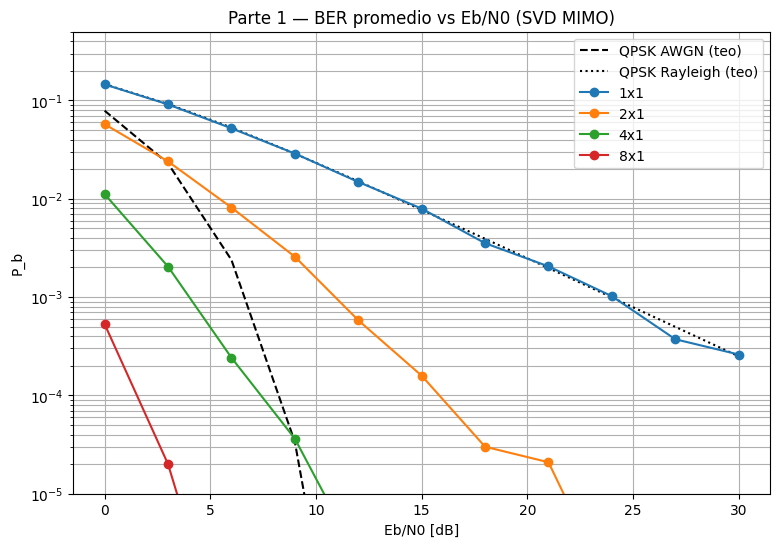

In [167]:
# Plot
plt.figure(figsize=(9,6))
EbN0_lin = 10**(EbN0_dB/10)
plt.semilogy(EbN0_dB, ber_qpsk_awgn(EbN0_lin), 'k--', label='QPSK AWGN (teo)')
plt.semilogy(EbN0_dB, ber_qpsk_rayleigh(EbN0_lin), 'k:', label='QPSK Rayleigh (teo)')
for (Nr,Nt), Pb in results.items():
    plt.semilogy(EbN0_dB, Pb, marker='o', label=f'{Nr}x{Nt}')
plt.xlabel('Eb/N0 [dB]')
plt.ylabel('P_b')
plt.ylim(10e-6, 0.5)
plt.grid(True, which='both')
plt.legend()
plt.title('Parte 1 — BER promedio vs Eb/N0 (SVD MIMO)')
plt.show()


Para un solo stream (d = 1), el desempeño mejora a medida que aumenta el número de antenas transmisoras Nt, ya que se obtiene ganancia de array.

En la gráfica se observa que las curvas 2×1, 4×1 y 8×1 presentan pendientes más pronunciadas y menor BER que el caso 1×1 para todo Eb/N0.

El caso 1×1 coincide con el desempeño teórico de un canal Rayleigh SISO, como es esperado.

## b) Simulación MIMO para configuraciones 1x1, 2x2, 4x4 y 8x8

In [168]:
EbN0_dB = np.arange(0, 31, 3)
configs = [(1,1),(2,2),(4,4),(8,8)]
Ns = 1000
Nreal = 10000

mode = "gpu" if gpu_available else "cpu"
use_gpu = (mode == "gpu")

print("\n>>> RUN MODE <<<")
print("Mode:", mode)

start = time.time()
results = {}
for (Nr, Nt) in configs:
    print(f"\n### Simulando {Nr}x{Nt} ###")
    results[(Nr,Nt)] = []
    for Eb in EbN0_dB:
        Eb_lin = 10**(Eb/10)
        Eb_lin, Pb = simulate_for_EbN0_gpu(Nr, Nt, Eb_lin, Ns, Nreal, seed=12345)
        results[(Nr,Nt)].append(Pb)

end = time.time()
print("\nTiempo total (s):", end-start)



>>> RUN MODE <<<
Mode: gpu

### Simulando 1x1 ###

### Simulando 2x2 ###

### Simulando 4x4 ###

### Simulando 8x8 ###

Tiempo total (s): 64.69241714477539


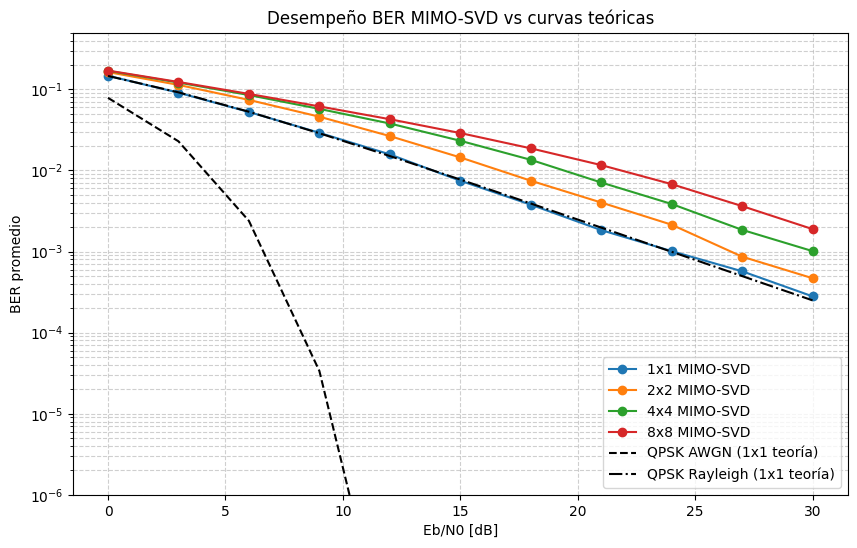

In [169]:
# Cell: Plot BER results for MIMO SVD vs AWGN/Rayleigh theory

plt.figure(figsize=(10,6))

# === Graficar resultados simulados ===
for (Nr, Nt), ber_list in results.items():
    label = f"{Nr}x{Nt} MIMO-SVD"
    plt.semilogy(EbN0_dB, ber_list, '-o', label=label)

# === Curva teórica QPSK AWGN (1x1) ===
EbN0_lin = 10**(EbN0_dB/10)
Pb_awgn = 0.5 * erfc(np.sqrt(EbN0_lin))
plt.semilogy(EbN0_dB, Pb_awgn, 'k--', label="QPSK AWGN (1x1 teoría)")

# === Curva teórica Rayleigh plano (1x1) ===
Pb_rayleigh = 0.5 * (1 - np.sqrt(EbN0_lin/(1+EbN0_lin)))
plt.semilogy(EbN0_dB, Pb_rayleigh, 'k-.', label="QPSK Rayleigh (1x1 teoría)")

plt.xlabel("Eb/N0 [dB]")
plt.ylabel("BER promedio")
plt.title("Desempeño BER MIMO-SVD vs curvas teóricas")
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.legend()
plt.ylim(1e-6, 0.5)
plt.show()


Cuando se transmiten varios streams simultáneamente (multiplexación espacial completa), el BER empeora al aumentar la dimensión MIMO, ya que cada canal propio recibe menos energía.

Se observa en la gráfica que el BER de 8×8 es peor que el de 4×4, y este peor que 2×2, mientras que 1×1 es el mejor caso.

Esto confirma que la multiplexación incrementa la tasa, pero reduce la SNR por stream, degradando el BER.

Todas las curvas se mantienen por encima de las curvas teóricas AWGN, acercándose mejor a la curva teórica Rayleigh a bajas Eb/N0.

## c) Simulación MIMO para configuraciones 2x1, 4x2 y 8x4

In [170]:
EbN0_dB = np.arange(0, 31, 3)
configs = [(2,1),(4,2),(8,4)]
Ns = 1000
Nreal = 10000

mode = "gpu" if gpu_available else "cpu"
use_gpu = (mode == "gpu")

print("\n>>> RUN MODE <<<")
print("Mode:", mode)

start = time.time()
results = {}
for (Nr, Nt) in configs:
    print(f"\n### Simulando {Nr}x{Nt} ###")
    results[(Nr,Nt)] = []
    for Eb in EbN0_dB:
        Eb_lin = 10**(Eb/10)
        Eb_lin, Pb = simulate_for_EbN0_gpu(Nr, Nt, Eb_lin, Ns, Nreal, seed=12345)
        results[(Nr,Nt)].append(Pb)

end = time.time()
print("\nTiempo total (s):", end-start)


>>> RUN MODE <<<
Mode: gpu

### Simulando 2x1 ###

### Simulando 4x2 ###

### Simulando 8x4 ###

Tiempo total (s): 31.299242734909058


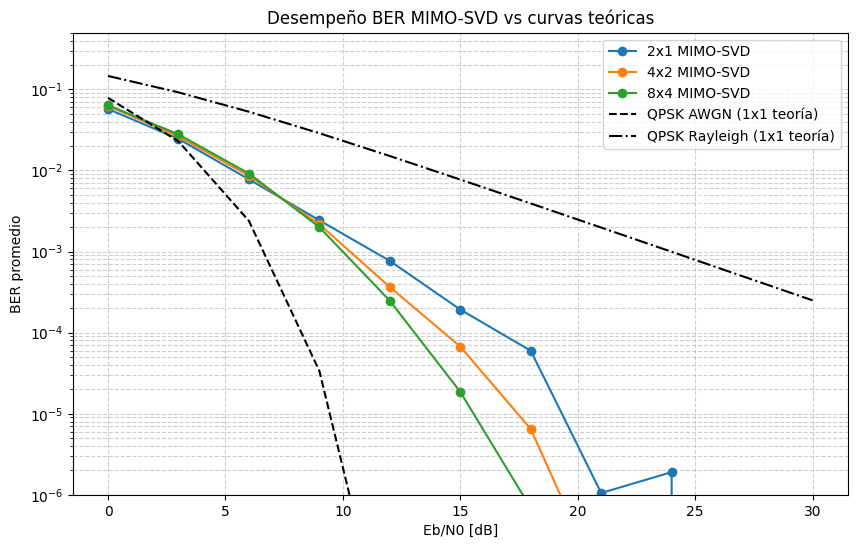

In [171]:
# Cell: Plot BER results for MIMO SVD vs AWGN/Rayleigh theory

plt.figure(figsize=(10,6))

# === Graficar resultados simulados ===
for (Nr, Nt), ber_list in results.items():
    label = f"{Nr}x{Nt} MIMO-SVD"
    plt.semilogy(EbN0_dB, ber_list, '-o', label=label)

# === Curva teórica QPSK AWGN (1x1) ===
EbN0_lin = 10**(EbN0_dB/10)
Pb_awgn = 0.5 * erfc(np.sqrt(EbN0_lin))
plt.semilogy(EbN0_dB, Pb_awgn, 'k--', label="QPSK AWGN (1x1 teoría)")

# === Curva teórica Rayleigh plano (1x1) ===
Pb_rayleigh = 0.5 * (1 - np.sqrt(EbN0_lin/(1+EbN0_lin)))
plt.semilogy(EbN0_dB, Pb_rayleigh, 'k-.', label="QPSK Rayleigh (1x1 teoría)")

plt.xlabel("Eb/N0 [dB]")
plt.ylabel("BER promedio")
plt.title("Desempeño BER MIMO-SVD vs curvas teóricas")
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.legend()
plt.ylim(1e-6, 0.5)
plt.show()

Aquí se transmite d = Nr streams, por lo que el sistema mantiene multiplexación, pero con más antenas en transmisión que en recepción.

En la gráfica se observa que a mayor dimensión (8×4), el desempeño no mejora; por el contrario, las curvas 2×1, 4×2 y 8×4 prácticamente se superponen, mostrando un desempeño muy similar.

Esto ocurre porque el número de canales propios transmitidos (d) es siempre igual al número de antenas receptoras, por lo que aumentar Nt no mejora la SNR disponible para cada stream.

Ninguno de los sistemas alcanza las curvas teóricas AWGN ni Rayleigh, lo cual es consistente con un MIMO con multiplexación y precodificación SVD, donde las potencias por stream se reparten y varios canales propios presentan ganancia reducida.